In [13]:
import numpy as np
import pandas as pd
from sksurv.nonparametric import kaplan_meier_estimator
from matplotlib import pyplot as plt
import pandas as pd
import yaml
from pathlib import Path
import anndata as ad

In [14]:
with open("../config.yaml", "r") as f:
    config = yaml.safe_load(f)

# Set up directories
results_dir = Path(config['results_dir'])
metadata_dir = Path(config['metadata_dir'])

In [16]:
adata = ad.read_h5ad(results_dir / "adata.h5ad")
extra_patient_info = pd.read_excel(metadata_dir / 'extra_patients_info.xlsx', sheet_name='Detailed info')
#get the survival time in months and event
extra_patient_info["survival_time_months"] = extra_patient_info["Survival after NMC diagnosis"].str.split(" month").str[0].astype(float)
adata.obs = adata.obs.merge(extra_patient_info, how='left', left_on='patient_ID', right_on='patient_ID')
adata.obs["patient_exp"] = adata.obs["patient_ID"].astype(str) + "_" + adata.obs["rois"].astype(str)

In [3]:
patients_metadata = pd.read_csv("/Users/jawadalaaedeen/Desktop/PhD/NMC/metadata/new_patients_metadata.csv")
patients_metadata["Status"] = True

In [4]:
patients_metadata

,patient_ID,age at diagnosis,sex,site,outcome,run,rois,outcome_group,exp_name,Status
0,NMC_2,6,m,lung hilus right,3,141.0,1,short_term survival,Run141_ROI1,True
1,NMC_9,27,m,central left lung,1,141.0,3,short_term survival,Run141_ROI3,True
2,NMC_9,27,m,central left lung,1,141.0,4,short_term survival,Run141_ROI4,True
3,NMC_12,12,f,cervical (including lymph node),38,92.0,5,long_term survival,Run92_ROI5,True
4,NMC_12,12,f,cervical (including lymph node),38,92.0,6,long_term survival,Run92_ROI6,True
5,NMC_13,13,f,"sample: metastasis left tigh, skin \nprimary s...",6,141.0,14,short_term survival,Run141_ROI14,True
6,NMC_13,13,f,"sample: metastasis left tigh, skin \nprimary s...",6,141.0,15,short_term survival,Run141_ROI15,True
7,NMC_14,21,f,extrahepatic bile ducts,24,141.0,8,long_term survival,Run141_ROI8,True
8,NMC_14,21,f,extrahepatic bile ducts,24,141.0,11,long_term survival,Run141_ROI11,True
9,NMC_15,27,m,lung,4,141.0,7,short_term survival,Run141_ROI7,True


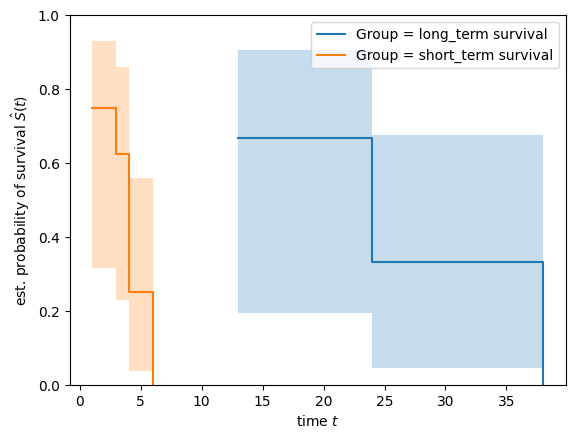

In [5]:
for i in ("long_term survival", "short_term survival"):
    mask_treat = patients_metadata["outcome_group"] == i
    time, survival_prob, conf_int = kaplan_meier_estimator(
    patients_metadata["Status"][mask_treat], 
    patients_metadata["outcome"][mask_treat]
    , conf_type="log-log"
    )
    plt.step(time, survival_prob, where="post", label=f"Group = {i}")
    plt.fill_between(time, conf_int[0], conf_int[1], alpha=0.25, step="post")

plt.ylim(0, 1)
plt.ylabel(r"est. probability of survival $\hat{S}(t)$")
plt.xlabel("time $t$")
plt.legend(loc="best")

In [ ]:
for treatment_type in ("standard", "test"):
    mask_treat = data_x["Treatment"] == treatment_type
    time_treatment, survival_prob_treatment, conf_int = kaplan_meier_estimator(
        data_y["Status"][mask_treat],
        data_y["Survival_in_days"][mask_treat],
        conf_type="log-log",
    )

    plt.step(time_treatment, survival_prob_treatment, where="post", label=f"Treatment = {treatment_type}")
    plt.fill_between(time_treatment, conf_int[0], conf_int[1], alpha=0.25, step="post")

plt.ylim(0, 1)
plt.ylabel(r"est. probability of survival $\hat{S}(t)$")
plt.xlabel("time $t$")
plt.legend(loc="best")

In [20]:
data_x, data_y = load_veterans_lung_cancer()
data_x

,Age_in_years,Celltype,Karnofsky_score,Months_from_Diagnosis,Prior_therapy,Treatment
0,69.0,squamous,60.0,7.0,no,standard
1,64.0,squamous,70.0,5.0,yes,standard
2,38.0,squamous,60.0,3.0,no,standard
3,63.0,squamous,60.0,9.0,yes,standard
4,65.0,squamous,70.0,11.0,yes,standard
...,...,...,...,...,...,...
132,65.0,large,75.0,1.0,no,test
133,64.0,large,60.0,5.0,no,test
134,67.0,large,70.0,18.0,yes,test
135,65.0,large,80.0,4.0,no,test


TypeError: expected pandas.DataFrame, but got <class 'numpy.ndarray'>

In [18]:
from sksurv.datasets import load_veterans_lung_cancer
from sksurv.linear_model import CoxPHSurvivalAnalysis
from sksurv.util import Surv

# Load data
data_x, data_y = load_veterans_lung_cancer()

# `data_y` is a structured array: convert to survival object
y = Surv.from_dataframe("Status", "Survival_in_days", data_y)

# Fit the Cox proportional hazards model
cox = CoxPHSurvivalAnalysis()
cox.fit(data_x, y)

# Plot the coefficients
coef = pd.Series(cox.coef_, index=data_x.columns)
coef.sort_values().plot(kind="barh")
plt.title("Cox Regression Coefficients")
plt.xlabel("Log hazard ratio")
plt.grid(True)
plt.tight_layout()
plt.show()

TypeError: expected pandas.DataFrame, but got <class 'numpy.ndarray'>